In [91]:
import geopandas as gpd
from shapely.ops import snap
import networkx as nx
from shapely.geometry import Point
import numpy as np

In [92]:
watershed = gpd.read_file("GIS/WATERSHEDS_CLIPPED.geojson")
watershed = watershed[watershed['NAME'] == 'Popes Head Creek']
watershed = watershed.to_crs('EPSG:26918')

In [93]:
s14 = gpd.read_file('stormnet/14.geojson')
s14 = s14.to_crs(watershed.crs).clip(watershed)

In [94]:
G = nx.DiGraph()
for idx, row in s14.iterrows():
    if row.geometry.geom_type != 'LineString':
        continue
    line = row.geometry
    
    start_point = Point(line.coords[0])
    end_point = Point(line.coords[-1])
    
    # Convert coordinate tuples to node IDs
    start_id = (round(start_point.x, 3), round(start_point.y, 3))
    end_id   = (round(end_point.x, 3),   round(end_point.y, 3))

    # Add nodes
    G.add_node(start_id, x=start_point.x, y=start_point.y)
    G.add_node(end_id,   x=end_point.x,   y=end_point.y)

    # Add edge with attributes from the row
    G.add_edge(
        start_id,
        end_id,
        pipe_id=row["STORMNET_ID"],
        length=row["ASSETLENGTH"],
        slope=row["SLOPE"],
        diameter=row["HEIGHT_DIA"],
        material=row["MATERIAL"],
        geometry=line
    )


In [110]:
infalls = []
outfalls = []

for node in G.nodes:
    if G.out_degree(node) == 0:
        outfalls.append(node)
        G.nodes[node]['type'] = 'outfall'
    elif G.in_degree(node) == 0:
        infalls.append(node)
        G.nodes[node]['type'] = 'infall'
    else:
        G.nodes[node]['type'] = 'junction'

print(f"Number of infalls: {len(infalls)}")
print(f"Number of outfalls: {len(outfalls)}")


Number of infalls: 1394
Number of outfalls: 961


In [6]:
import pickle
with open('pipe_graph.pickle', 'wb') as f:
    pickle.dump(G, f)

In [99]:
node_geoms = []
node_ids = []
node_type = []

for n, data in G.nodes(data=True):
    node_ids.append(n)
    node_type.append(data["type"])
    node_geoms.append(Point(data["x"], data["y"]))

nodes_gdf = gpd.GeoDataFrame(
    {"node_id": node_ids, "node_type": node_type},
    geometry=node_geoms,
    crs=s14.crs
)

edge_geoms = []
edge_ids = []
for u, v, data in G.edges(data=True):
    edge_geoms.append(data["geometry"])
    edge_ids.append(data["pipe_id"])
edges_gdf = gpd.GeoDataFrame( {"pipe_id": edge_ids}, geometry=edge_geoms, crs=s14.crs )


In [96]:
s13 = gpd.read_file('stormnet/13.geojson')
s13 = s13.to_crs(watershed.crs).clip(watershed)

In [83]:
outfalls = s13[(s13.TYPE == 'Outfall') | (s13.TYPE == 'MS4 OUTFALL')]

In [97]:
drainage_sources = ['Inlet', 'Infall']
is_source = [s13['TYPE'].str.contains(source) for source in drainage_sources]
is_source = np.logical_or(*is_source)
is_source = np.where(is_source.isna(), False, is_source)
drainage = s13[is_source]

In [74]:
node_sindex = nodes_gdf.sindex

nearest_nodes = []
distances = []

for idx, of in drainage.iterrows():
    possible_matches_idx = list(node_sindex.nearest(of.geometry, 1))
    candidates = nodes_gdf.iloc[np.concatenate(possible_matches_idx)].copy()
    candidates["dist"] = candidates.geometry.distance(of.geometry)
    nearest = candidates.sort_values("dist").iloc[0]
    nearest_nodes.append(nearest["node_id"])
    distances.append(nearest["dist"])

drainage["nearest_node"] = nearest_nodes
drainage["distance_to_node"] = distances
nodes_gdf["is_inlet"] = nodes_gdf["node_id"].isin(nearest_nodes)

/home/javkt/anaconda3/envs/py10/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/home/javkt/anaconda3/envs/py10/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [75]:
node_sindex = nodes_gdf.sindex

nearest_nodes = []
distances = []

for idx, of in outfalls.iterrows():
    possible_matches_idx = list(node_sindex.nearest(of.geometry, 1))
    candidates = nodes_gdf.iloc[np.concatenate(possible_matches_idx)].copy()
    candidates["dist"] = candidates.geometry.distance(of.geometry)
    nearest = candidates.sort_values("dist").iloc[0]
    nearest_nodes.append(nearest["node_id"])
    distances.append(nearest["dist"])

outfalls["nearest_node"] = nearest_nodes
outfalls["distance_to_node"] = distances
nodes_gdf["is_outfall"] = nodes_gdf["node_id"].isin(nearest_nodes)

/home/javkt/anaconda3/envs/py10/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/home/javkt/anaconda3/envs/py10/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



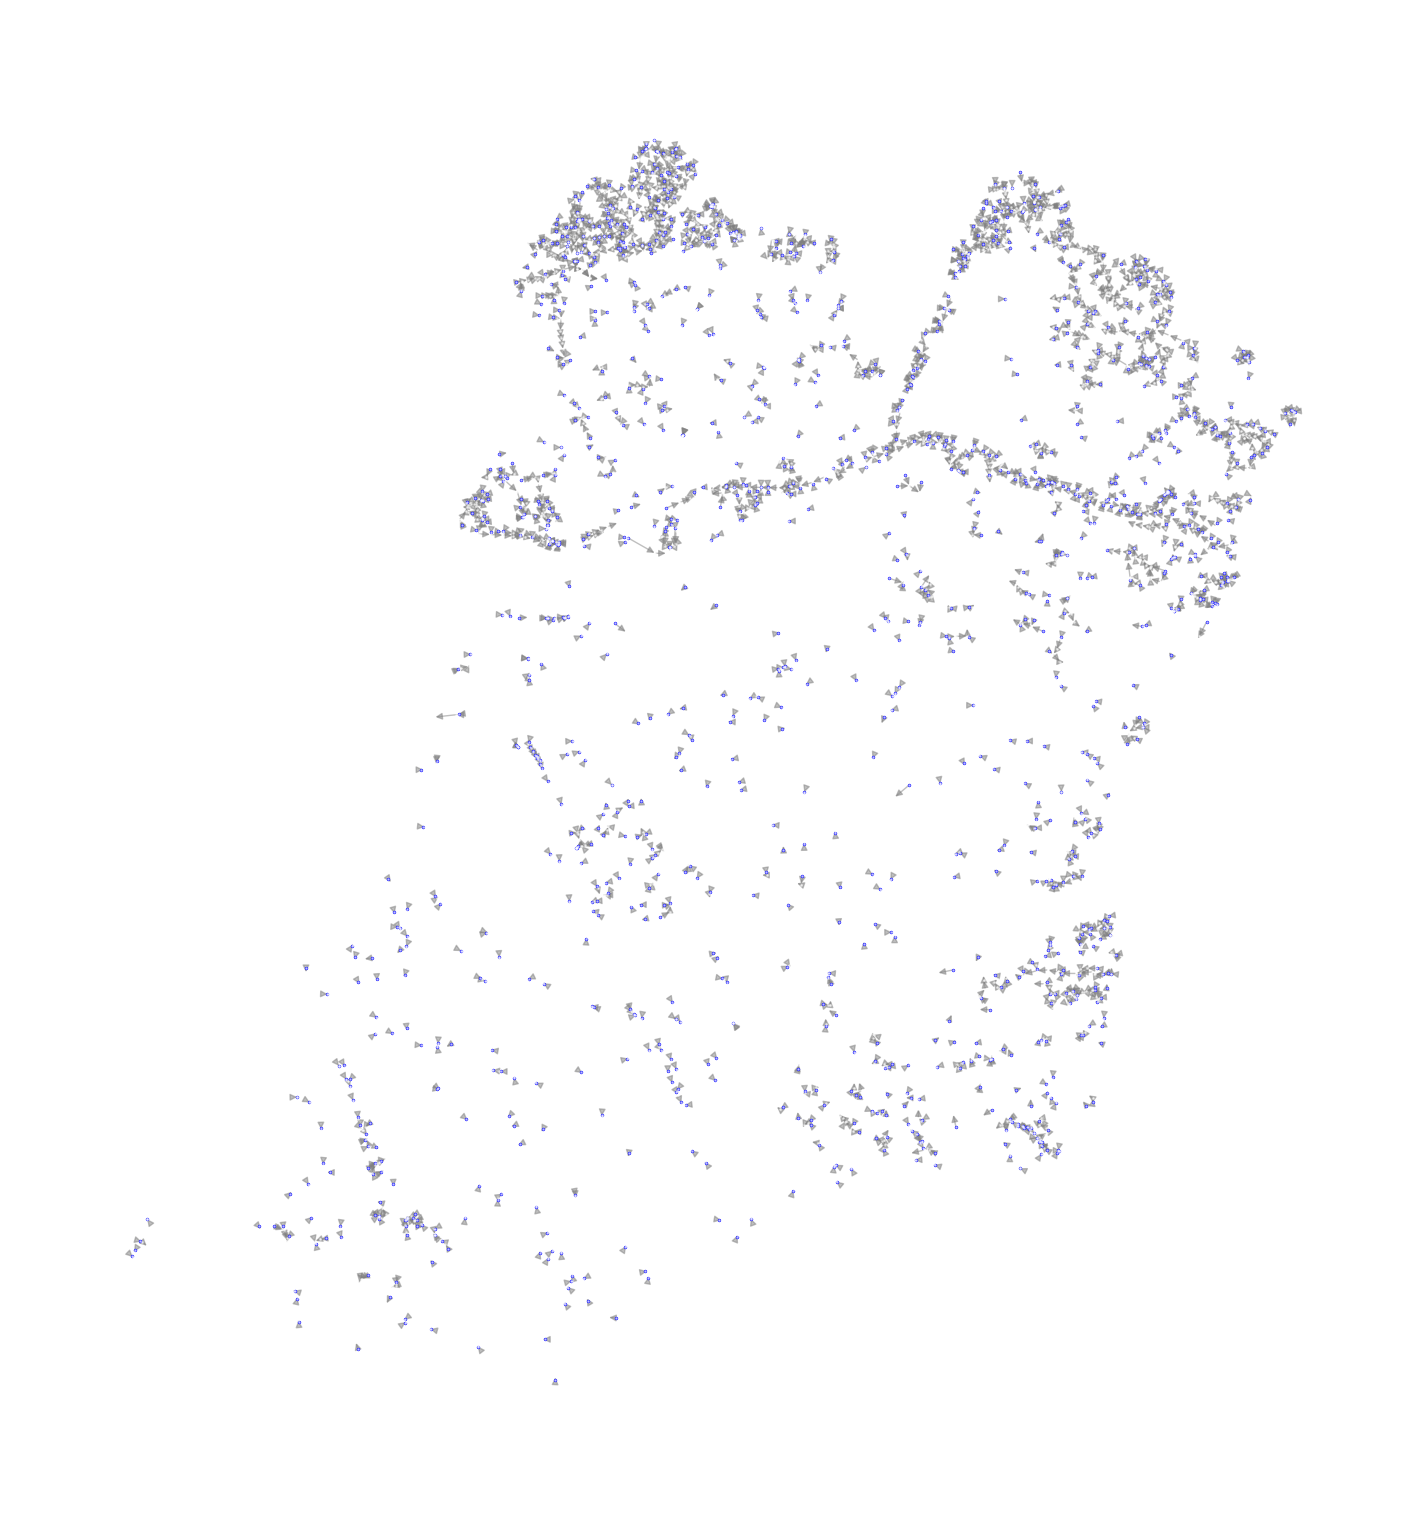

In [107]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(15,15))
nx.draw(
    G,
    pos = {node: (data["x"], data["y"]) for node, data in G.nodes(data=True)},
    node_size=1,
    node_color="white",
    edge_color="gray",
    width=1, alpha=0.5
)
# plt.scatter(
#     x=nodes_gdf[nodes_gdf.is_outfall].geometry.x,
#     y=nodes_gdf[nodes_gdf.is_outfall].geometry.y,
#     c="blue",
#     s=2
# )
plt.scatter(
    x=nodes_gdf[nodes_gdf.node_type == 'infall'].geometry.x,
    y=nodes_gdf[nodes_gdf.node_type == 'infall'].geometry.y,
    c="blue",
    s=2
)
# plt.scatter(
#     x=nodes_gdf[nodes_gdf.node_type == 'outfall'].geometry.x,
#     y=nodes_gdf[nodes_gdf.node_type == 'outfall'].geometry.y,
#     c="green",
#     s=3
# )
# plt.scatter(
#     x=drainage.geometry.x,
#     y=drainage.geometry.y,
#     c="red",
#     s=2
# )
plt.gca().set_aspect("equal")
plt.show()
